# **Data Pre-Processing**


## Finding Duplicate rows


Install the needed libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<p>
Load the data into pandas
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Identify and Analyze Duplicates


In [10]:
## Count the number of duplicate rows in the dataset.
duplicated_count = df.duplicated().sum()
print(duplicated_count)

## Looking at structure
duplicated = df[df.duplicated()] 
duplicated.head()

20


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Analyze Characteristics of Duplicates

In [14]:
## Identify relevant columns: MainBranch, Employment, and RemoteWork

subset_cols = ['MainBranch', 'Employment', 'RemoteWork']
duplicates_subset = df[df.duplicated(subset=subset_cols, keep=False)]
print(f"Number of rows with duplicate values in {subset_cols}: {len(duplicates_subset)}")

# Display a few rows to understand their structure
print("First few duplicate rows based on subset:")
print(duplicates_subset.head())

# Analyze which other columns are frequently identical in these rows
# Group by the subset and look at the value counts of other columns
grouped = duplicates_subset.groupby(subset_cols)

# Example: See consistency in 'EdLevel' across duplicate groups
print("\nExamples of EdLevel variation within duplicate groups:")
for name, group in grouped:
    print(f"\nGroup: {name}")
    print(group['EdLevel'].value_counts())

Number of rows with duplicate values in ['MainBranch', 'Employment', 'RemoteWork']: 65290
First few duplicate rows based on subset:
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contr

### Visualize Duplicates Distribution

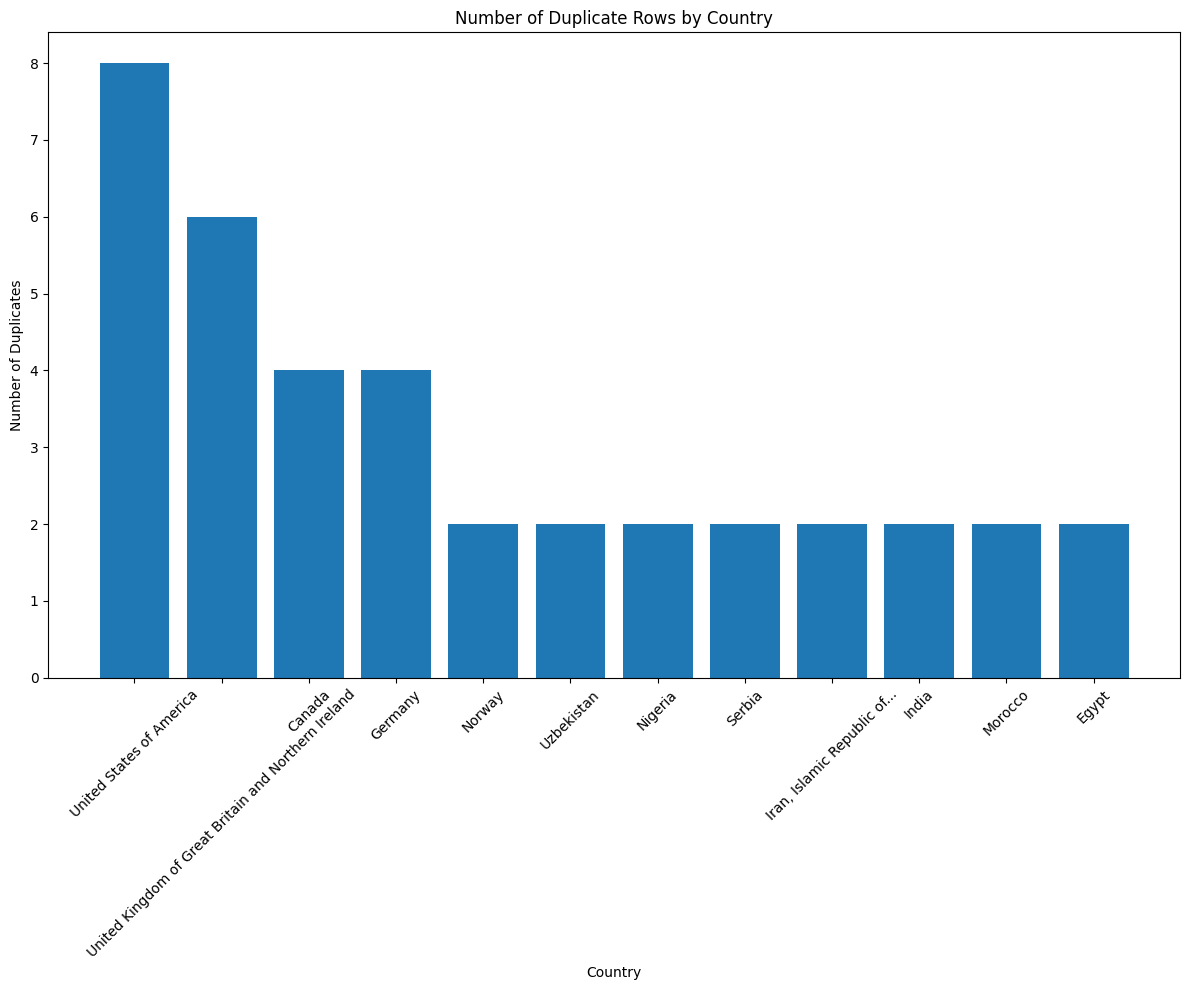

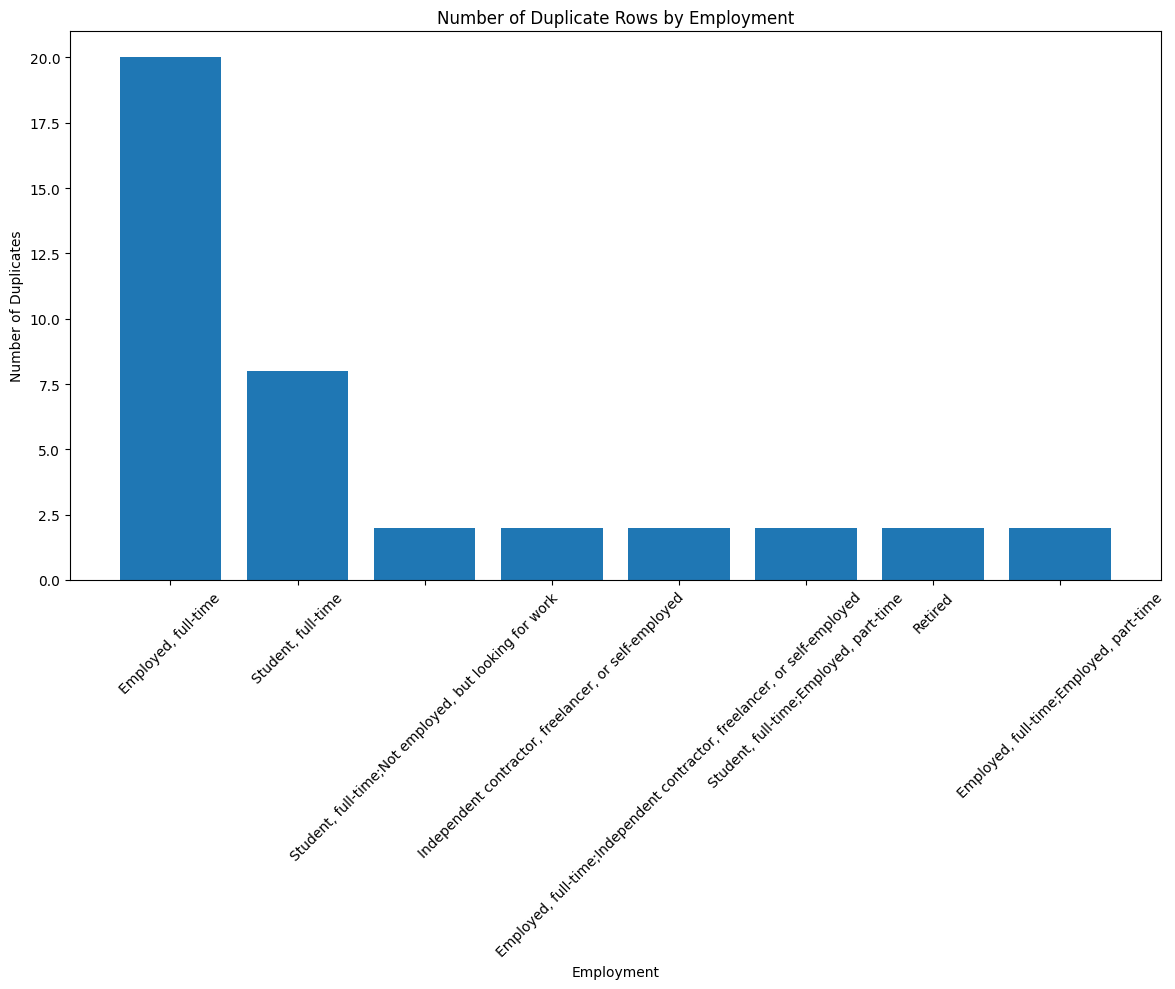

In [29]:
## Visualize categories of distribution for duplicate rows
duplicates = df[df.duplicated(keep=False)]

# Count duplicates by Country and Employment
country_counts = duplicates['Country'].value_counts()
employment_counts = duplicates['Employment'].value_counts()

# Distribution of duplicates by Country - Bar plot

plt.figure(figsize=(12, 10))
plt.bar(x=country_counts.index, height=country_counts.values)
# sns.barplot(x=country_counts.index, y=country_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Number of Duplicate Rows by Country")
plt.xlabel("Country")
plt.ylabel("Number of Duplicates")
plt.tight_layout()
plt.show()

# # Distribution of duplicates by Employment - Pie plot

plt.figure(figsize=(12, 10))
plt.bar(x=employment_counts.index, height=employment_counts.values)
# sns.barplot(x=country_counts.index, y=country_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Number of Duplicate Rows by Employment")
plt.xlabel("Employment")
plt.ylabel("Number of Duplicates")
plt.tight_layout()
plt.show()

### Strategic Removal of Duplicates

In [ ]:
## Critical columns for uniqueness: MainBranch, Country, Employment, 
## RemoteWork, YearsCode, EdLevel, and DevType

# Group cleaned data  
subset_cols = ['MainBranch', 'Country', 'Employment', 'RemoteWork', 'YearsCode', 'EdLevel', 'DevType']
cleaned_df = df.drop_duplicates(subset=subset_cols, keep='first')

### Finding Missing Values

In [5]:
# Identiy missing values for all columns 
missing = cleaned_df.isnull()
missing.head()

In [ ]:
# Plot a heatmap of missing data

plt.figure(figsize=(15, 8))
sns.heatmap(missing,
            cbar=False, # Hide the color bar
            cmap='viridis', # Color map
            yticklabels=False) # Hide row labels for readability
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [ ]:
# Count the number of missing rows for a specific column (Employment)
missing_remote = df['RemoteWork'].isnull().sum()
print(f"Number of missing rows in 'RemoteWork': {missing_remote}")

### Impute missing values

In [ ]:
# Replace empty strings and strings with only whitespace
cleaned_df.replace(['None', r'^\s*$'], np.nan, regex=True, inplace=True)
cleaned_df.isnull().sum()

In [ ]:
# Impute missing values in the RemoteWork column with the most frequent value
freq = cleaned_df['RemoteWork'].mode()[0]
cleaned_df['RemoteWork'].fillna(freq, inplace=True)
remote_missing = cleaned_df['RemoteWork'].isnull().sum()
print(cleaned_df['RemoteWork'].isnull().sum())

In [8]:
# Impute missing values in CodingActivities with forward-fill
cleaned_df['CodingActivities'].fillna(method='ffill', inplace=True) 
cleaned_df['CodingActivities'].isnull().sum()

In [ ]:
# Impute missing values in the ConvertedCompYearly column with the average 
mean = cleaned_df['ConvertedCompYearly'].mean() 
cleaned_df['ConvertedCompYearly'].replace(np.nan, mean, inplace=True)

In [ ]:
# Visualize the distribution of RemoteWork column after imputation
remote_counts = cleaned_df['RemoteWork'].value_counts()
plt.figure(figsize=(8, 5))
sns.countplot(x='RemoteWork', data=cleaned_df)
plt.show()

In [ ]:
# Check for any compensation-related columns. Describe their distribution
cleaned_df.columns.tolist()
cols_comp = ['CompTotal', 'ConvertedCompYearly']
cleaned_df[cols_comp].info()
cleaned_df[cols_comp].isnull().sum()
cleaned_df[cols_comp].describe()

# Logarithmic distribution scale helps compress skewed data
plt.figure(figsize=(10, 6)) sns.histplot(df['ConvertedCompYearly'].dropna(), bins=50) plt.xscale('log')  
plt.title('Distribution of Annual Compensation (log scale)') 
plt.xlabel('Converted Compensation (USD, log scale)') 
plt.ylabel('Count')plt.figure(figsize=(10, 6)) 
sns.histplot(cleaned_df['ConvertedCompYearly'].dropna(), bins=50) plt.xscale('log') 
plt.show()

## Data Normalization

In [ ]:
# Filtering compensation column
filtered = cleaned_df[(cleaned_df['ConvertedCompYearly'] > 1000) & (cleaned_df['ConvertedCompYearly'] < 250000)]

# Normalize ConvertedCompYearly using Min-Max Scaling
filtered['ConvertedCompYearly_MinMax'] = ( filtered['ConvertedCompYearly'] - filtered['ConvertedCompYearly'].min() ) / ( filtered['ConvertedCompYearly']max() - filtered['ConvertedCompYearly'].min() )

# Normalize ConvertedCompYearly using Z-Score Normalization
filtered['ConvertedCompYearly_Zscore'] = ( filtered['ConvertedCompYearly'] -filtered['ConvertedCompYearly'].mean() ) / filtered['ConvertedCompYearly'].std()

# Log transform the normalized values for better visualization of data
filtered['log_ConvertedCompYearly'] = np.log10(filtered['ConvertedCompYearly'])
filtered['log_ConvertedCompYearly_MinMax'] = np.log10(filtered['ConvertedCompYearly_MinMax']) 
filtered['log_ConvertedCompYearly_Zscore'] = np.log10(filtered['ConvertedCompYearly_Zscore'])

# Visualize the distribution of ConvertedCompYearly, ConvertedCompYearly_Normalized and ConvertedCompYearly_Zscore
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.kdeplot(filtered['log_ConvertedCompYearly'].dropna(), ax=ax1,label='ConvertedCompYearly', color='blue', fill=False)
sns.kdeplot(filtered['log_ConvertedCompYearly_MinMax'].dropna(), ax=ax1,label='ConvertedCompYearly_MinMax', color='green', fill=False)
sns.kdeplot(filtered['log_ConvertedCompYearly_Zscore'].dropna(), ax=ax1,label='ConvertedCompYearly_Zscore', color='red', fill=False)
ax1.set_title("KDE Plot of Compensation, normalized and un-normalized")
ax1.set_xlabel("Log10(ConvertedCompYearly)")
ax1.legend()
plt.show()

## Data wrangling

### Standardizing entries by mapping inconsistent values to a consistent format

In [ ]:
# Target columns: Country, EdLevel 
country_mapping = {
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea", 
    "Nomadic": None, # Replace with NaN or None to mark as missing
    }

# Apply mapping 
cleaned_df['Country'] = cleaned_df['Country'].replace(country_mapping)

### Categorical Variables Encoding

In [ ]:
# Create df with “indicator”/dummy variables

employment_dummies = cleaned_df['Employment'].str.get_dummies(sep=';') 

# Rename 
employment_dummies.rename(columns={
    "Employed, full-time":"Employment_Employed, full-time",
    "Employed, part-time":"Employment_Employed, part-time",
    "I prefer not to say":"Employment_I prefer not to say",
    "Independent contractor, freelancer, or self-employed": "Employment_Independent contractor, freelancer, or self-employed",
    "Not employed, and not looking for work":"Employment_Not employed, and not looking for work",
    "Not employed, but looking for work":"Employment_Not employed, but looking for work", 
    "Retired":"Employment_Retired",
    "Student, full-time, part-time": "Employment_Student, full-time", 
    "Student, part-time":"Employment_Student, part-time",
}, inplace=True)

# Join the indicator variable df to the original df 
cleaned_df = pd.concat([cleaned_df, employment_dummies], axis=1)

### Feature Engineering

In [ ]:
## Create a new column ExperienceLevel based on the YearsCodePro column

# Cleaning YearsCodePro
cleaned_df['YearsCodePro'].replace({'Less than 1 year':'0.5', 
                                    'More than 50 years':'51'}, inplace=True)
cleaned_df['YearsCodePro'] = cleaned_df.to_numeric(df['YearsCodePro'], errors='coerce') 
clean_years = cleaned_df['YearsCodePro'].dropna()

# Binning 
bins = np.linspace(clean_years.min(), clean_years.max(), 4)
group_names = ['Low', 'Medium', 'High']
df['ExperienceLevel'] = pd.cut( df['YearsCodePro'], bins, labels=group_names,␣
↪include_lowest=True )